# ESA-ADB Mission 1 — EDA & Baseline Shift Analysis

14 years of real spacecraft telemetry. 190 anomaly events buried in 14.7M rows. <br>
This notebook walks through the data, the shift, and which channels are actually usable. <br>

## Key findings

- **Event lengths span five orders of magnitude** — single-sample blips up to 116k-row episodes. Any detector needs to handle both extremes.
- **Most events are visually subtle** at the full mission scale; only the longest produce obvious deviations in raw signals.
- **Train and test distributions differ** for most channels (mean KS = 0.43). A subset of **10 channels jumps in lock-step** at the train→test boundary (KS ≈ 0.96–0.97) — this is the dramatic shift that breaks naive reconstruction approaches.
- **Only 15 channels are stable** across train and test (KS < 0.25), including a tight, high-correlation cluster at channels 41–46.
- **Heavy block redundancy** in the correlation matrix means a small subset of channels carries most of the joint variance.
- **No missing values**, no further data cleaning required.

| Metric | Value |
|---|---|
| Train rows | 14,728,321 |
| Test rows | 521,280 |
| Scored channels | 58 |
| Anomaly events (train) | 190 |
| Anomaly rate | 10.48% |
| Shortest event | 1 sample |
| Longest event | 116,061 samples |
| Event length median | 602 samples |
| Missing values | 0 |
| Mean KS distance (train vs test) | 0.43 |
| Max KS distance | 0.97 (channel_15) |
| Lock-step shifted channels (KS > 0.9) | 10 |
| Stable channels (KS < 0.25) | 15 |
| Highest telecommand lift | ~9.5× (telecommand_352 / 353 / 354) |

## Setup

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

NOM  = '#4878d0'   # muted blue
ANOM = '#c44e52'   # muted red
ACC  = '#55a868'   # muted green
MID  = '#d99a9c'   # dusty rose (lighter ANOM, for moderate drift)

# Kaggle
ROOT = Path('/kaggle/input/esa-adb-challenge')

# Local
# ROOT = Path('../data/raw')

In [62]:
# Load data

# Data path
ROOT = Path('../data/raw')
# ROOT = Path('/kaggle/input/esa-adb-challenge')

train           = pd.read_parquet(ROOT / 'train.parquet')
test            = pd.read_parquet(ROOT / 'test.parquet')
target_channels = pd.read_csv(ROOT / 'target_channels.csv')['target_channels'].tolist()

print(f'train  {train.shape}   anom rate {train.is_anomaly.mean():.2%}')
print(f'test   {test.shape}')
print(f'channels: {len(target_channels)} scored / {sum(c.startswith("channel_") for c in train.columns)} total')

train  (14728321, 89)   anom rate 10.48%
test   (521280, 88)
channels: 58 scored / 76 total


## Anomaly events

190 contiguous events ranging from a single sample to 116k rows. The length distribution spans five orders of magnitude. Events are scattered unevenly across the 14-year mission — clustering hints at fault correlation across mission phases.


In [63]:
# Find anomaly segments

def get_segments(y):
    y = np.asarray(y, dtype=bool)
    diff = np.diff(np.concatenate([[False], y, [False]]).astype(np.int8))
    starts = np.where(diff ==  1)[0]
    ends   = np.where(diff == -1)[0]
    return pd.DataFrame({'start': starts, 'end': ends - 1, 'length': ends - starts})

events = get_segments(train['is_anomaly']) # fn from ml_logic/data.py
seg_df = pd.DataFrame(events)

print(f'Total anomaly segments (events): {len(events)}')
print(f'Min segment length  : {seg_df["length"].min():,}')
print(f'Max segment length  : {seg_df["length"].max():,}')
print(f'Mean segment length : {seg_df["length"].mean():,.1f}')
print(f'Median segment length: {seg_df["length"].median():,.0f}')
seg_df.head(10)

Total anomaly segments (events): 190
Min segment length  : 1
Max segment length  : 116,061
Mean segment length : 8,126.9
Median segment length: 602


,start,end,length
0,115383,155649,40267
1,161604,161614,11
2,165175,165855,681
3,194565,194575,11
4,225361,263520,38160
5,327272,333647,6376
6,339469,340149,681
7,429016,429035,20
8,437161,437179,19
9,489940,489958,19


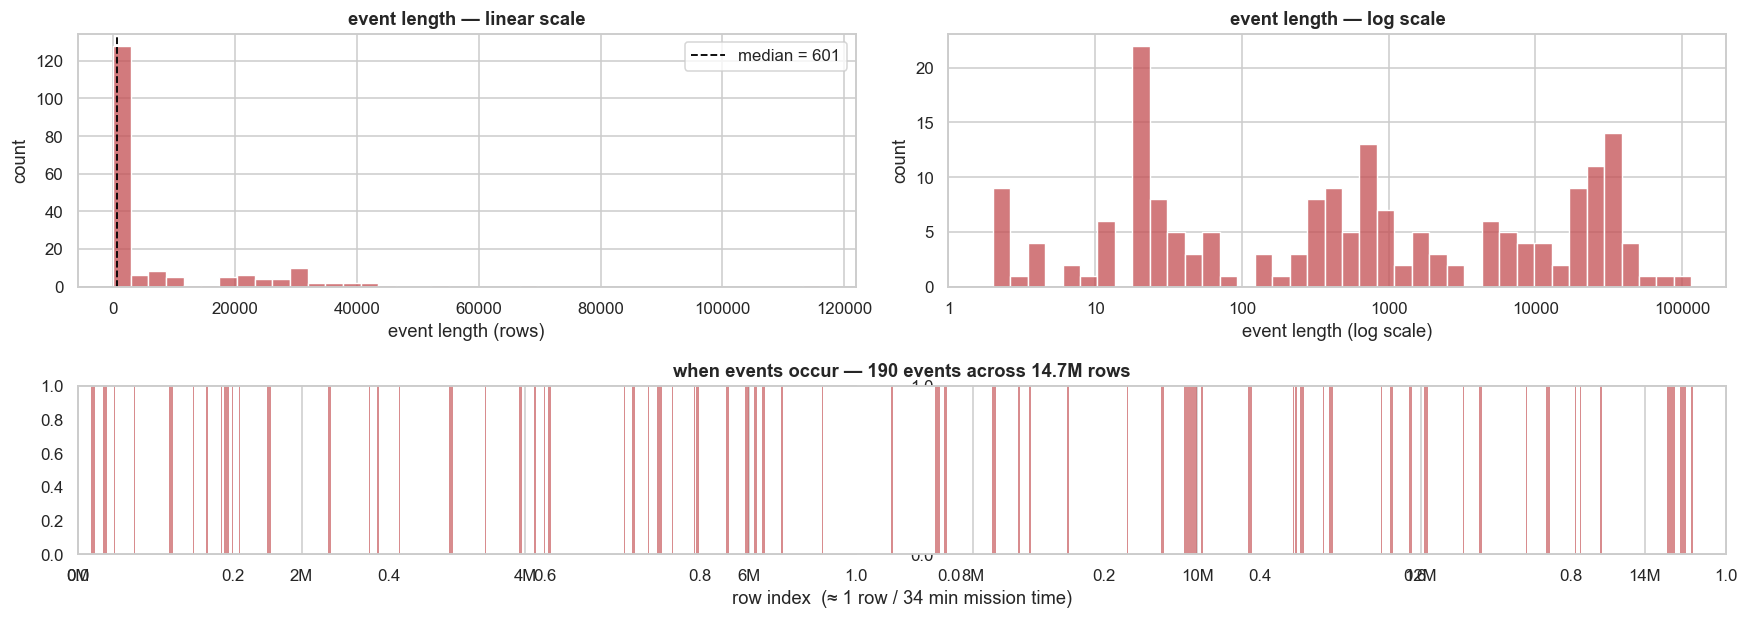

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6),
                         gridspec_kw={'height_ratios': [3, 2]})

# event length, linear scale
ax = axes[0, 0]
sns.histplot(events['length'], bins=40, ax=ax, color=ANOM, edgecolor='white')
ax.axvline(events['length'].median(), color='black', ls='--', lw=1.2,
           label=f'median = {int(events["length"].median())}')
ax.set_xlabel('event length (rows)')
ax.set_ylabel('count')
ax.set_title('event length — linear scale', fontweight='bold')
ax.legend()

# event length, log scale
ax = axes[0, 1]
sns.histplot(np.log10(events['length'] + 1), bins=40, ax=ax, color=ANOM, edgecolor='white')
ticks = [1, 10, 100, 1_000, 10_000, 100_000]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([str(t) for t in ticks])
ax.set_xlabel('event length (log scale)')
ax.set_ylabel('count')
ax.set_title('event length — log scale', fontweight='bold')

# temporal distribution (spans both columns)
ax = plt.subplot2grid((2, 2), (1, 0), colspan=2, fig=fig)
for _, r in events.iterrows():
    ax.axvspan(r.start, r.end, color=ANOM, alpha=0.65, lw=0)
ax.set_xlim(0, len(train))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('row index  (≈ 1 row / 34 min mission time)')
ax.set_title(f'when events occur — {len(events)} events across {len(train)/1e6:.1f}M rows',
             fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()

## Time series

Telemetry from seven representative channels at the full mission scale, downsampled to 1% for display. Anomaly regions shaded in red. At this scale most events are subtle — only the longest produce visible deviations.


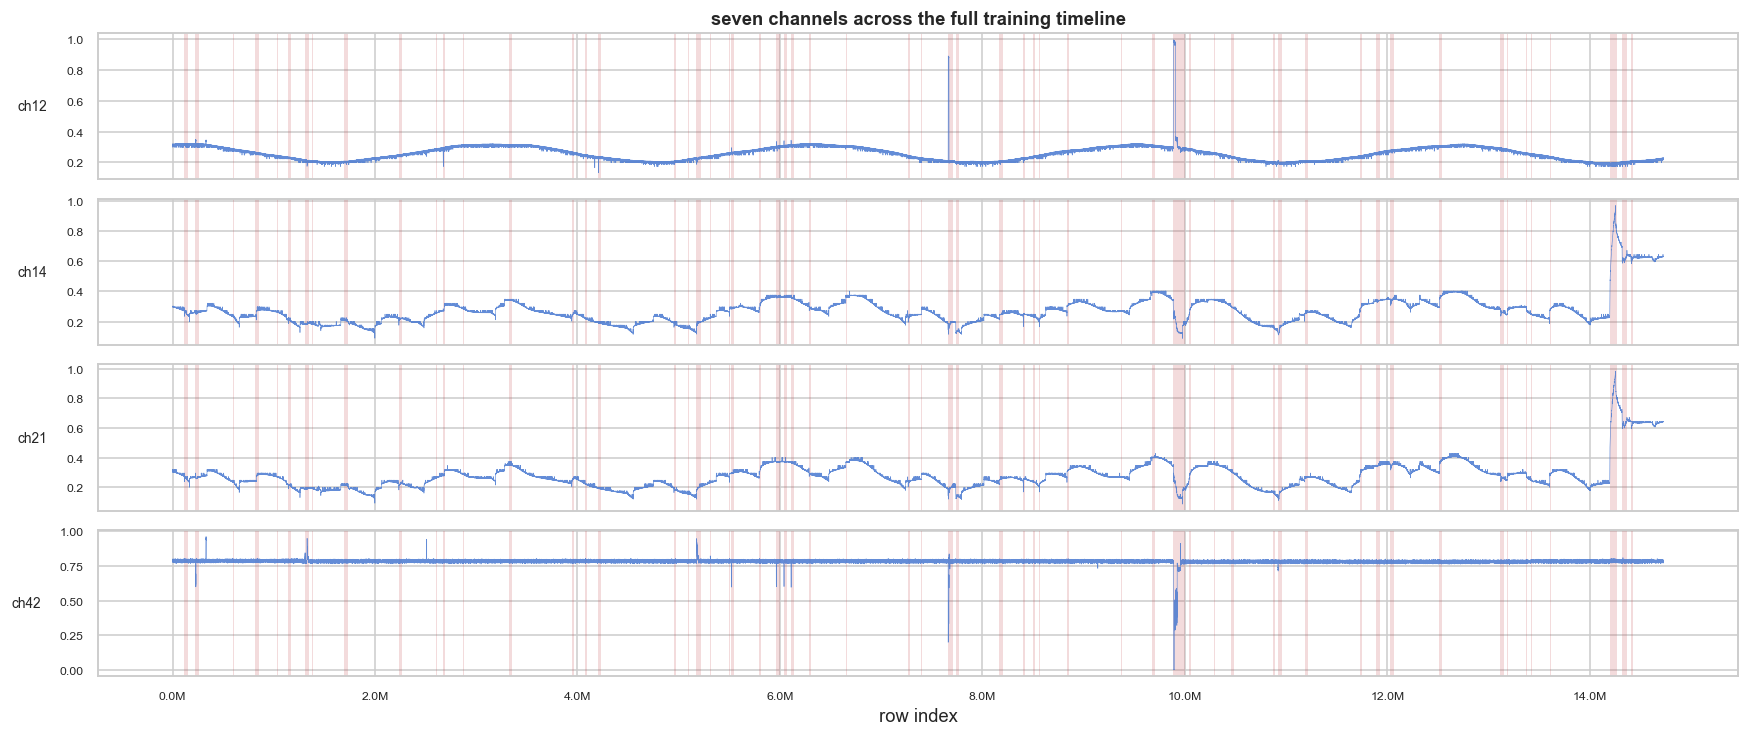

In [65]:
SHOW_CH = ['channel_12', 'channel_14', 'channel_21','channel_42']
DS = 100   # show every 100th row

fig, axes = plt.subplots(len(SHOW_CH), 1, figsize=(16, 1.7 * len(SHOW_CH)), sharex=True)
for ax, ch in zip(axes, SHOW_CH):
    x = np.arange(0, len(train), DS)
    y = train[ch].values[::DS]
    ax.plot(x, y, lw=0.4, color=NOM, alpha=0.85)
    # shade events longer than 100 rows so they're visible at this scale
    for _, e in events[events.length > 100].iterrows():
        ax.axvspan(e.start, e.end, color=ANOM, alpha=0.2, lw=0)
    ax.set_ylabel(ch.replace('channel_', 'ch'), fontsize=9, rotation=0,
                  labelpad=22, va='center')
    ax.tick_params(labelsize=8)

axes[0].set_title('seven channels across the full training timeline',
                  fontweight='bold')
axes[-1].set_xlabel('row index')
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()

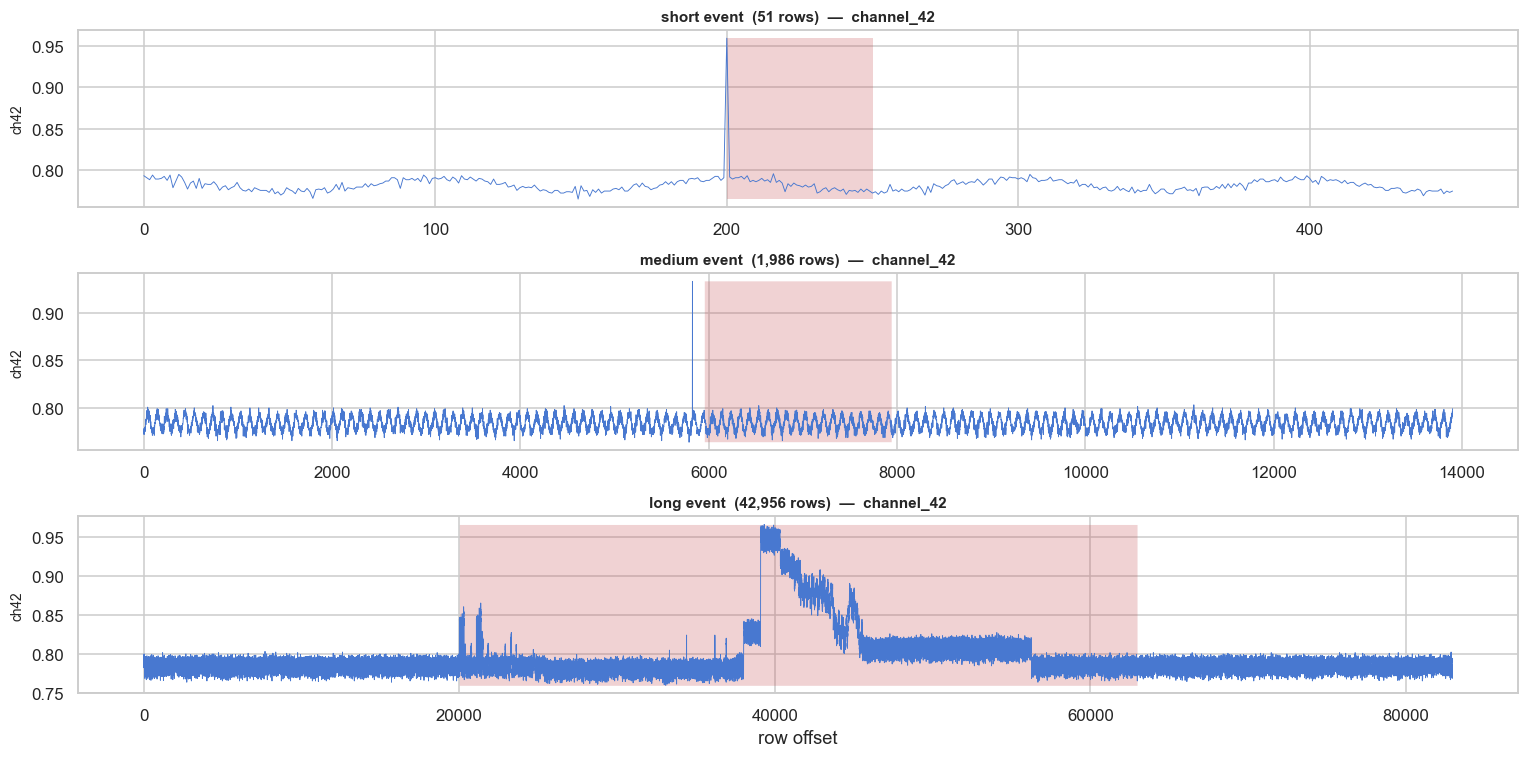

In [66]:
# three events at different scales, same channel for comparable amplitudes
ZOOM_CH = 'channel_42'
short_ev  = events[events.length.between(20, 100)].sample(1, random_state=1).iloc[0]
medium_ev = events[events.length.between(500, 2_000)].sample(1, random_state=2).iloc[0]
long_ev   = events[events.length.between(20_000, 50_000)].sample(1, random_state=3).iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 7))
for ax, e, label in zip(
    axes,
    [short_ev, medium_ev, long_ev],
    ['short', 'medium', 'long'],
):
    PAD = min(20_000, max(200, int(e.length) * 3))
    i0  = max(0, int(e.start) - PAD)
    i1  = min(len(train), int(e.end) + PAD)
    win = train.iloc[i0:i1]
    x = np.arange(len(win))
    y = win[ZOOM_CH].values
    a = win['is_anomaly'].values.astype(bool)
    ax.plot(x, y, lw=0.6, color=NOM)
    ax.fill_between(x, y.min(), y.max(), where=a, color=ANOM, alpha=0.25, lw=0)
    ax.set_title(f'{label} event  ({int(e.length):,} rows)  —  {ZOOM_CH}',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(ZOOM_CH.replace('channel_', 'ch'), fontsize=9)

axes[-1].set_xlabel('row offset')
plt.tight_layout()

## The baseline shift

Most channels show some distributional drift between train and test (mean KS = 0.43), but **10 channels jump in lock-step** to a new baseline at the train→test boundary (KS ≈ 0.96–0.97, +4.5 to +6.7 σ) and stay there through the entire 521k-row test set. Reconstruction models trained on the pre-shift regime flag the whole post-shift period as anomalous — the event-wise score still catches every event, but the ESA correction penalises the row-level false positive rate, and F0.5 collapses.

This dramatic lock-step cluster is the central challenge of the dataset.


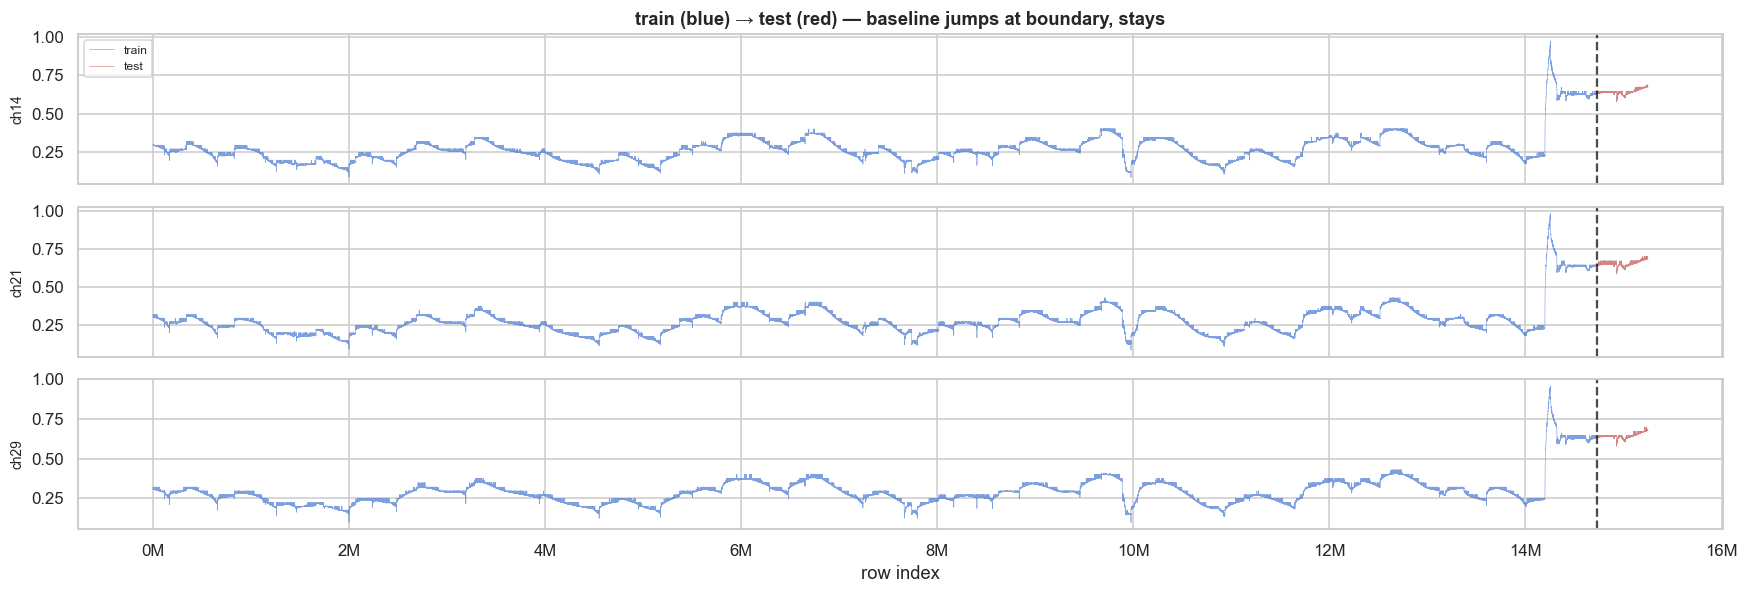

In [67]:
SHIFT_CH = ['channel_14', 'channel_21', 'channel_29']
DS = 50
N_TR = len(train)

fig, axes = plt.subplots(len(SHIFT_CH), 1, figsize=(16, 5.5), sharex=True)
for ax, ch in zip(axes, SHIFT_CH):
    ax.plot(range(0, N_TR, DS), train[ch].values[::DS],
            lw=0.4, color=NOM, alpha=0.7, label='train')
    ax.plot(range(N_TR, N_TR + len(test), DS), test[ch].values[::DS],
            lw=0.4, color=ANOM, alpha=0.7, label='test')
    ax.axvline(N_TR, color='black', lw=1.5, ls='--', alpha=0.7)
    ax.set_ylabel(ch.replace('channel_', 'ch'), fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
axes[0].set_title('train (blue) → test (red) — baseline jumps at boundary, stays',
                  fontweight='bold')
axes[-1].set_xlabel('row index')
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()

### KS distance 

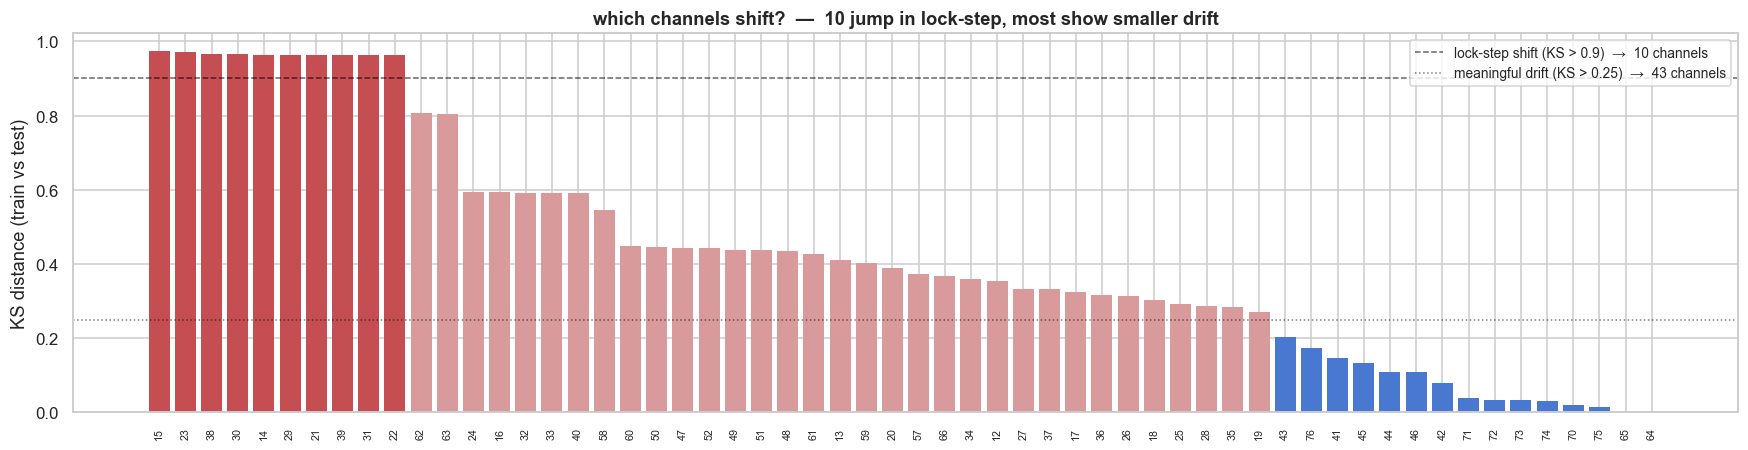

In [68]:
# KS distance between train and test for every scored channel
rng     = np.random.default_rng(42)
s_train = rng.choice(len(train), 40_000, replace=False)
s_test  = rng.choice(len(test),  min(40_000, len(test)), replace=False)

ks = pd.Series({
    ch: ks_2samp(train[ch].values[s_train], test[ch].values[s_test]).statistic
    for ch in target_channels
}).sort_values(ascending=False)

# colour by severity: red (lock-step) → ochre (drift) → blue (stable)
def ks_color(v):
    if v > 0.9:  return ANOM
    if v > 0.25: return MID
    return NOM

fig, ax = plt.subplots(figsize=(16, 4.2))
ax.bar(range(len(ks)), ks.values,
       color=[ks_color(v) for v in ks.values], edgecolor='none', width=0.8)
ax.axhline(0.9,  color='black', lw=1, ls='--', alpha=0.6,
           label=f'lock-step shift (KS > 0.9)  →  {(ks > 0.9).sum()} channels')
ax.axhline(0.25, color='black', lw=1, ls=':',  alpha=0.5,
           label=f'meaningful drift (KS > 0.25)  →  {(ks > 0.25).sum()} channels')
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([c.replace('channel_', '') for c in ks.index],
                   rotation=90, fontsize=7)
ax.set_ylabel('KS distance (train vs test)')
ax.set_title('which channels shift?  —  10 jump in lock-step, most show smaller drift',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()


## Channel taxonomy

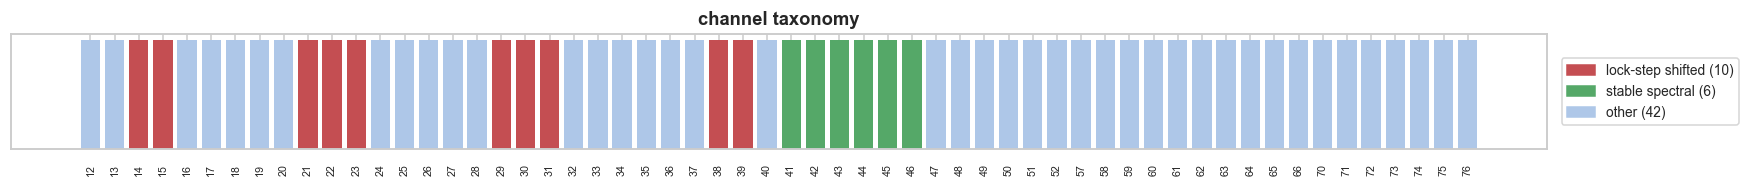

In [69]:
# channel taxonomy — three groups by behaviour
LOCKSTEP = [f'channel_{i}' for i in [14, 15, 21, 22, 23, 29, 30, 31, 38, 39]]
SPECTRAL = [f'channel_{i}' for i in range(41, 47)]

palette = {'lock-step shifted (10)':       ANOM,
           'stable spectral (6)':          ACC,
           'other (42)':                   '#aec7e8'}

def group_of(c):
    if c in LOCKSTEP: return 'lock-step shifted (10)'
    if c in SPECTRAL: return 'stable spectral (6)'
    return 'other (42)'

fig, ax = plt.subplots(figsize=(16, 1.8))
ax.bar(range(len(target_channels)), [1] * len(target_channels),
       color=[palette[group_of(c)] for c in target_channels], edgecolor='none')
ax.set_xticks(range(len(target_channels)))
ax.set_xticklabels([c.replace('channel_', '') for c in target_channels], rotation=90, fontsize=7)
ax.set_yticks([])
ax.set_title('channel taxonomy', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in palette.items()],
          fontsize=9, loc='center left', bbox_to_anchor=(1.005, 0.5))
plt.tight_layout()


## Channel correlation matrix

Pairwise Pearson correlation across all 58 scored channels. The matrix shows clear block structure — channels cluster into highly correlated groups carrying near-redundant information. The natural numbering already places related channels next to each other, so blocks 12–20, 21–28, 29–37, and 41–46 are visible directly.


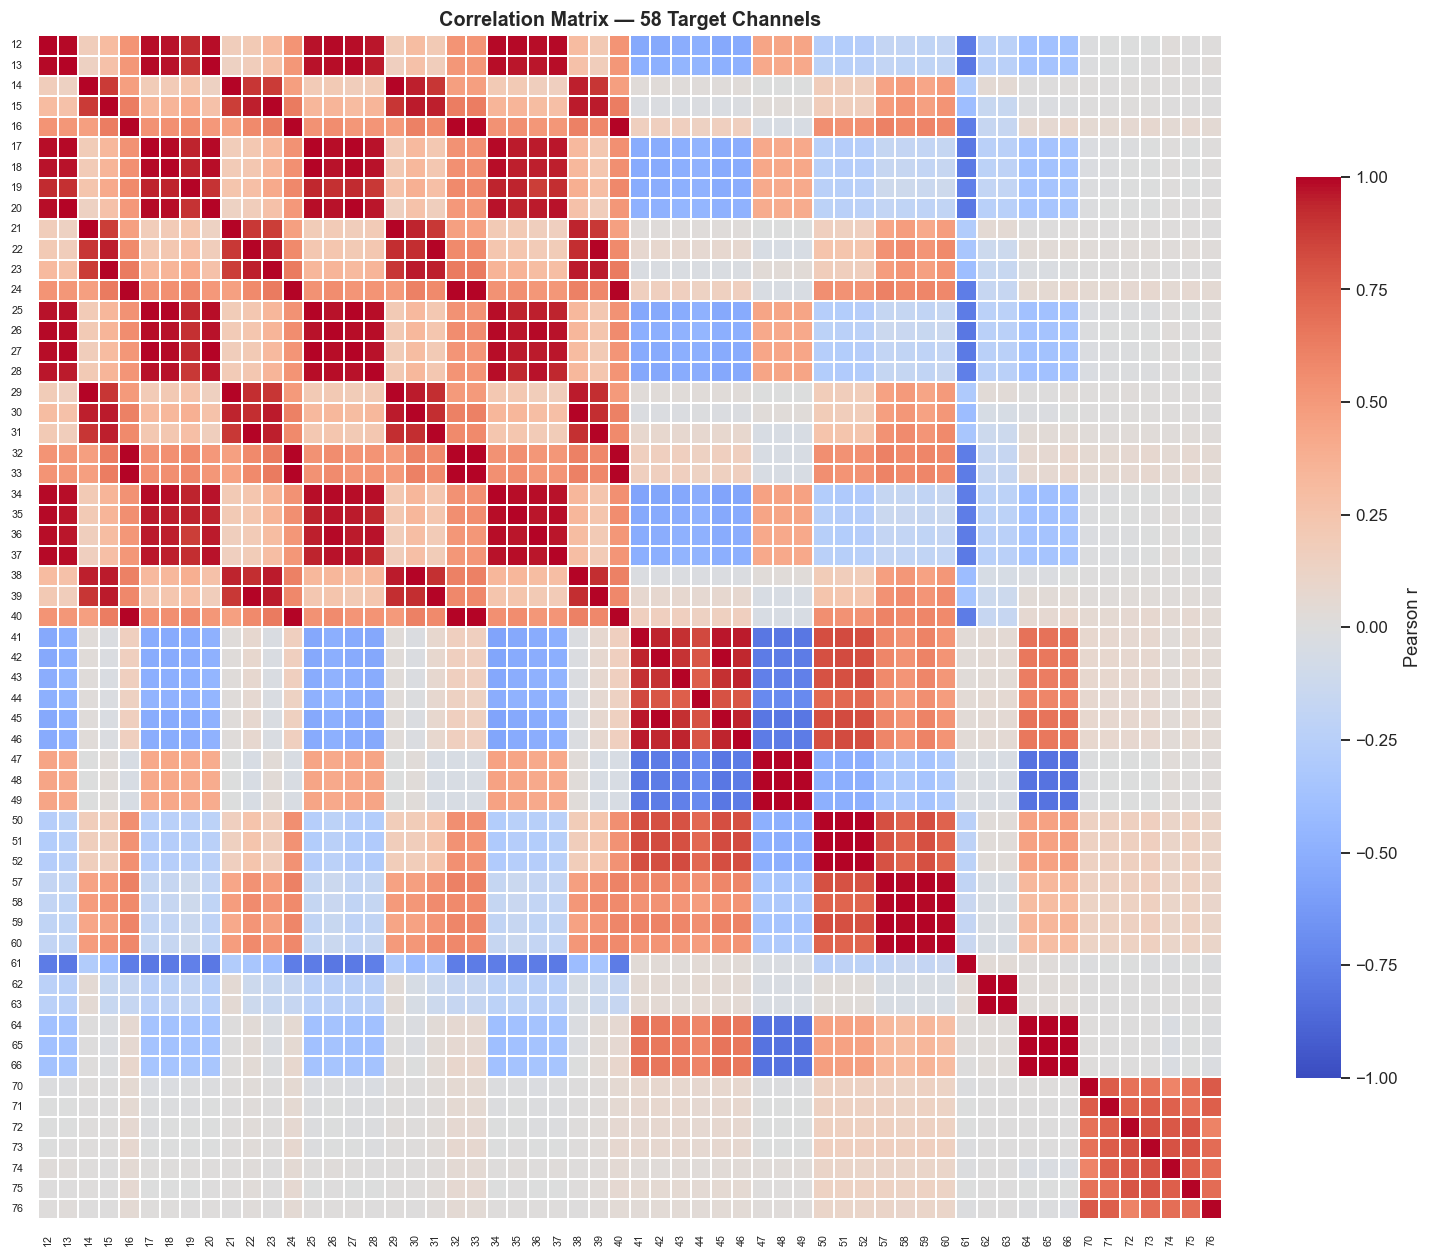

In [70]:
# correlation matrix — target channels only, sampled for speed
sample = train[target_channels].sample(100_000, random_state=42)
corr   = sample.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.2, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            xticklabels=[c.replace('channel_', '') for c in corr.columns],
            yticklabels=[c.replace('channel_', '') for c in corr.index])
ax.tick_params(labelsize=7)
ax.set_title('Correlation Matrix — 58 Target Channels', fontsize=13, fontweight='bold')
plt.tight_layout()
